In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
inventory_df = pd.read_csv("../../data/tidewarehouseinventorysim.csv")

In [4]:
len(inventory_df)

21900

In [5]:
inventory_df.columns

Index(['Date', 'FC_ID', 'IsMetro', 'StockStart', 'Demand', 'DemandFulfilled',
       'Backorders', 'StockEnd', 'ReorderPoint', 'OrderPlaced', 'OrderQty',
       'LeadTimeFloat', 'SafetyStock'],
      dtype='object')

In [6]:
inventory_df.describe()

,StockStart,Demand,DemandFulfilled,Backorders,StockEnd,ReorderPoint,OrderPlaced,OrderQty,LeadTimeFloat,SafetyStock
count,21900.000000,21900.000000,21900.000000,21900.000000,21900.000000,21900.00000,21900.000000,21900.000000,21900.000000,21900.000000
mean,2057.012283,96.659315,96.270274,0.389041,1960.742009,520.25000,0.164247,98.017260,3.875500,178.450000
std,2164.713491,61.006490,60.917388,5.999784,2157.507326,271.99001,0.370508,271.924524,2.306453,109.157187
min,0.000000,0.000000,0.000000,0.000000,0.000000,136.00000,0.000000,0.000000,0.300000,36.000000
25%,488.000000,52.000000,52.000000,0.000000,412.000000,334.75000,0.000000,0.000000,1.975000,107.750000
50%,1142.000000,82.000000,82.000000,0.000000,1045.500000,447.00000,0.000000,0.000000,3.900000,173.000000
75%,2902.000000,126.000000,126.000000,0.000000,2793.250000,786.00000,0.000000,0.000000,5.172500,217.250000
max,10724.000000,450.000000,450.000000,267.000000,10656.000000,1023.00000,1.000000,1908.000000,9.640000,516.000000


In [16]:
inventory_df.iloc[:, 2:]

,IsMetro,StockStart,Demand,DemandFulfilled,Backorders,StockEnd,ReorderPoint,OrderPlaced,OrderQty,LeadTimeFloat,SafetyStock
0,False,610,8,8,0,602,523,0,0,7.18,92
1,True,1770,120,120,0,1650,1023,0,0,4.23,516
2,False,454,30,30,0,424,342,0,0,3.39,138
3,False,224,90,90,0,134,168,1,202,2.21,36
4,True,518,135,135,0,383,402,1,421,1.34,241
...,...,...,...,...,...,...,...,...,...,...,...
21895,True,3993,135,135,0,3858,864,0,0,6.19,121
21896,True,5327,150,150,0,5177,871,0,0,4.26,359
21897,False,1180,82,82,0,1098,377,0,0,3.57,163
21898,False,2736,120,120,0,2616,467,0,0,4.73,183


         Date  FC_ID  IsMetro  StockStart  Demand  DemandFulfilled  \
0  2021-01-01  FC_01    False         610       8                8   
1  2021-01-01  FC_02     True        1770     120              120   
2  2021-01-01  FC_03    False         454      30               30   
3  2021-01-01  FC_04    False         224      90               90   
4  2021-01-01  FC_05     True         518     135              135   

   Backorders  StockEnd  ReorderPoint  OrderPlaced  OrderQty  LeadTimeFloat  \
0           0       602           523            0         0           7.18   
1           0      1650          1023            0         0           4.23   
2           0       424           342            0         0           3.39   
3           0       134           168            1       202           2.21   
4           0       383           402            1       421           1.34   

   SafetyStock  
0           92  
1          516  
2          138  
3           36  
4          241  
Da

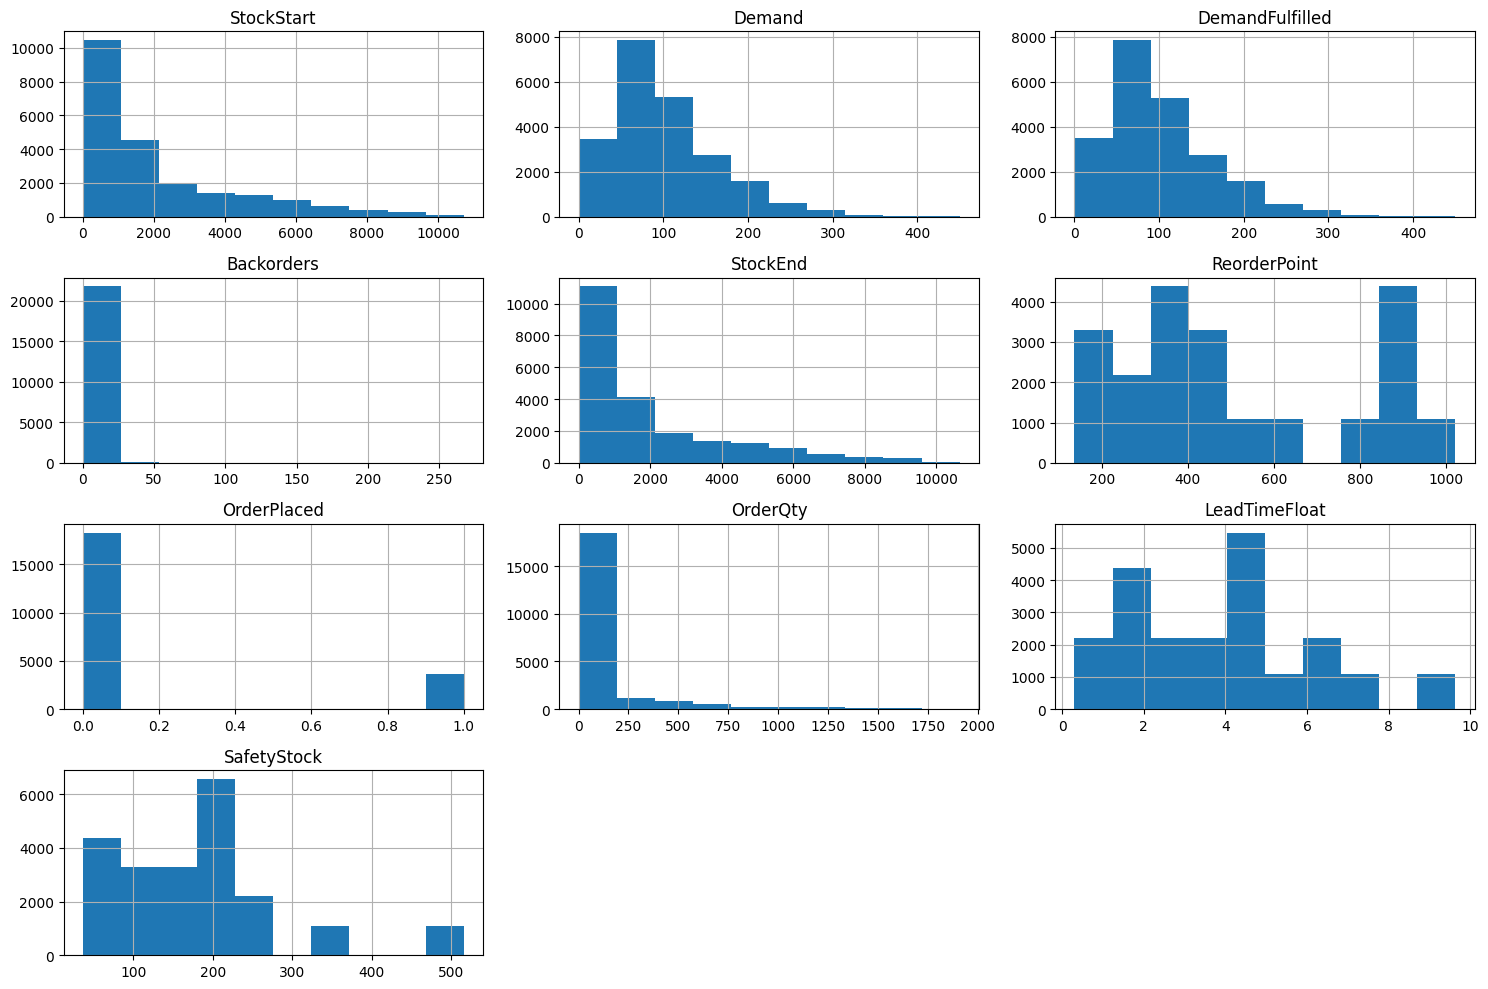

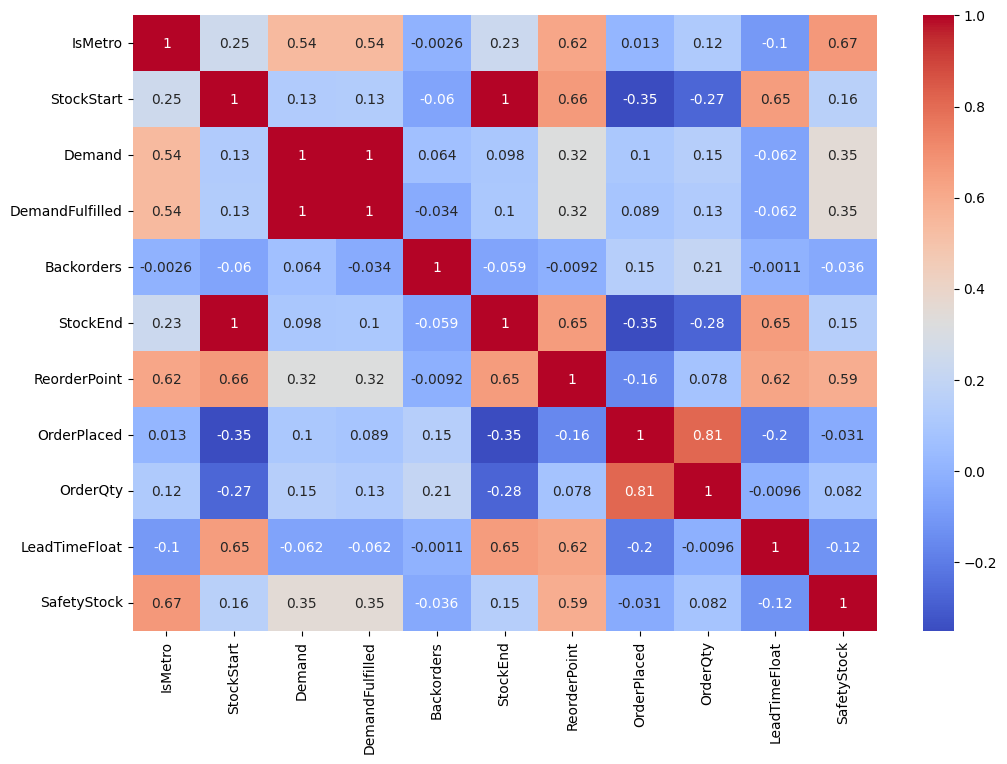

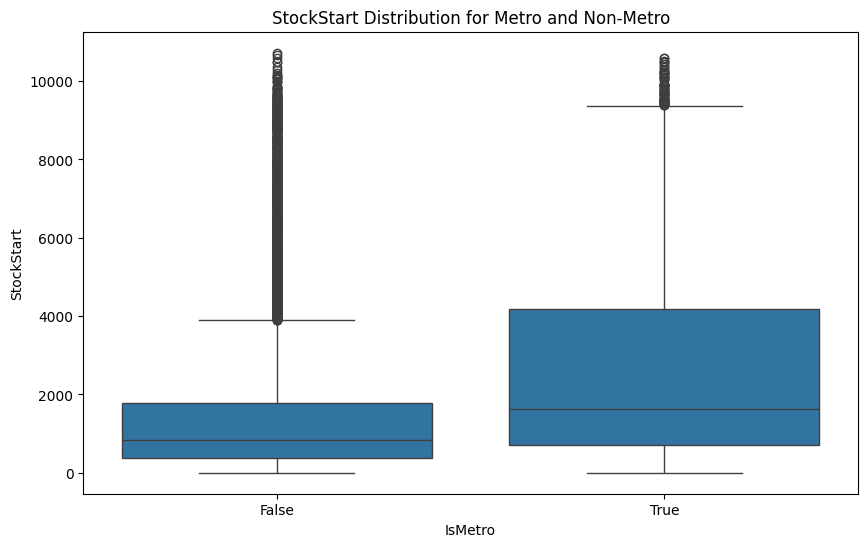

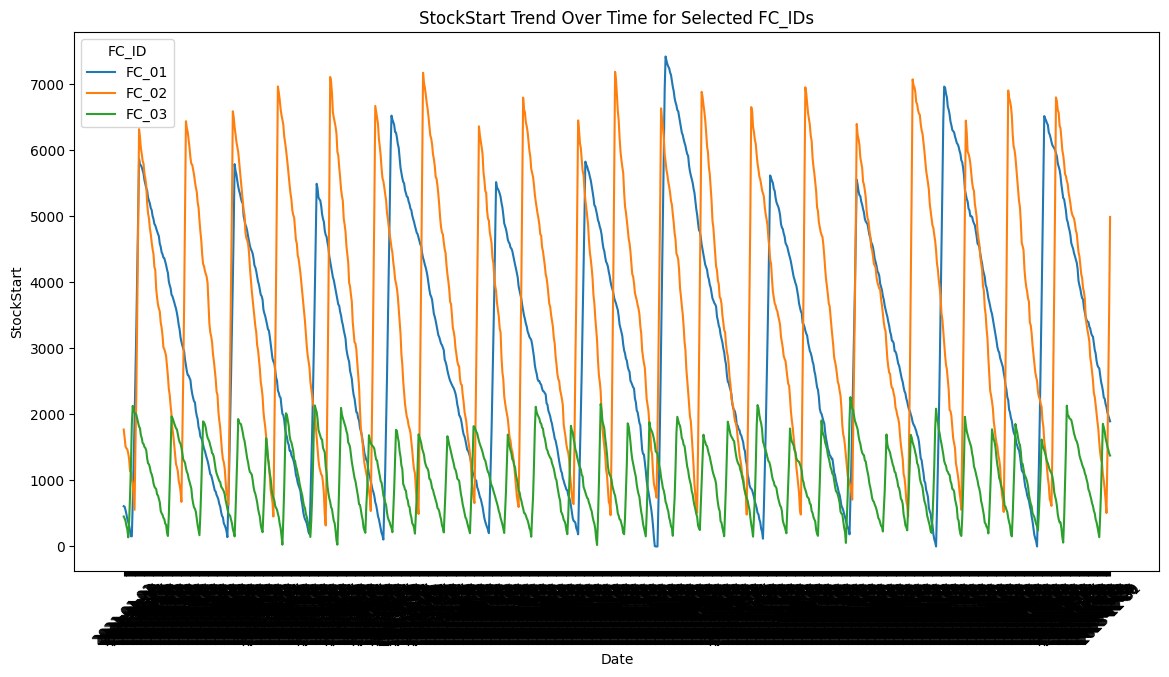

In [17]:
# Display the first few rows of the dataframe
print(inventory_df.head())

# Check for missing values
print(inventory_df.isnull().sum())

# Plot the distribution of numerical columns
inventory_df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(inventory_df.iloc[:, 2:].corr(), annot=True, cmap='coolwarm')
plt.show()

# Plot the distribution of 'StockStart' for Metro and Non-Metro
plt.figure(figsize=(10, 6))
sns.boxplot(x='IsMetro', y='StockStart', data=inventory_df)
plt.title('StockStart Distribution for Metro and Non-Metro')
plt.show()

# Plot the trend of 'StockStart' over time for a specific FC_ID
plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='StockStart', hue='FC_ID', data=inventory_df[inventory_df['FC_ID'].isin(['FC_01', 'FC_02', 'FC_03'])])
plt.title('StockStart Trend Over Time for Selected FC_IDs')
plt.xticks(rotation=45)
plt.show()